Successfully imported necessary libraries for exploritory analysis

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels as sm
from scipy.stats import pearsonr
import seaborn as sns

# Import dataframes for Exploratory Data Analysis

In [59]:
life_expectancy = pd.read_csv('../Datasets/Cleaned_datasets/Life_expectancy_cleaned_1.csv').drop(columns=['Unnamed: 0'])

highest_grossing = pd.read_csv('../Datasets/Cleaned_datasets/Top_Grossing_Countries-per_capita.csv').drop(columns=['Unnamed: 0'])
lowest_grossing = pd.read_csv('../Datasets/Cleaned_datasets/Lowest_Grossing_Countries-per_capita.csv').drop(columns=['Unnamed: 0'])


In [60]:
descriptive_stats_life_exp = pd.read_csv('../Datasets/Cleaned_datasets/Descriptive_Statistics_Dfs/Descriptive_Stats-All_Life_expectancy.csv').drop(columns=['Unnamed: 0'])

descriptive_stats_life_exp_top_gdp = pd.read_csv('../Datasets/Cleaned_datasets/Descriptive_Statistics_Dfs/Descriptive_Stats-Top_GDP_Life_expectancy.csv').drop(columns=['Unnamed: 0'])

descriptive_stats_life_exp_bottom_gdp = pd.read_csv('../Datasets/Cleaned_datasets/Descriptive_Statistics_Dfs/Descriptive_Stats-Bottom_GDP_Life_expectancy.csv').drop(columns=['Unnamed: 0'])

In [61]:
descriptive_stats_adult_mortality = pd.read_csv('../Datasets/Cleaned_datasets/Descriptive_Statistics_Dfs/Descriptive_Stats-All_Adult_Mortality.csv')

# Explore relationship between life expectancy and GDP per capita

Display life expectancy descriptive analysis stats for lowest gdp per capita countries for the countries falling into those categories in 2015.

## Summary Statistics

In [62]:
#region life expectancy 
print(life_expectancy.describe(include='all'))
print(descriptive_stats_life_exp_bottom_gdp)


            country         year  life_expectancy  adult_mortality  \
count          2816  2816.000000      2816.000000      2816.000000   
unique          176          NaN              NaN              NaN   
top     Afghanistan          NaN              NaN              NaN   
freq             16          NaN              NaN              NaN   
mean            NaN  2007.500000        69.172695       191.154347   
std             NaN     4.610591         9.121567       117.134134   
min             NaN  2000.000000        41.960000        45.140000   
25%             NaN  2003.750000        63.065000       103.975000   
50%             NaN  2007.500000        71.420000       162.150000   
75%             NaN  2011.250000        76.082500       256.200000   
max             NaN  2015.000000        83.790000       743.500000   

        infant_deaths  under_five_deaths     bmi_male   bmi_female  \
count     2816.000000        2816.000000  2816.000000  2816.000000   
unique            N

Also display life expectancy descriptive analysis stats for highest gdp per capita countries for the countries falling into those categories in 2015.

In [63]:
print(descriptive_stats_life_exp_top_gdp)

    year   mean    max  max_country  minimum  median
0   2000  77.58  81.08        Japan    72.04   77.90
1   2001  77.91  81.42        Japan    72.11   78.09
2   2002  78.05  81.69        Japan    72.23   78.18
3   2003  78.31  81.76        Japan    72.40   78.41
4   2004  78.74  82.03        Japan    72.48   78.99
5   2005  78.95  81.96        Japan    72.76   79.19
6   2006  79.20  82.32        Japan    72.86   79.34
7   2007  79.42  82.51        Japan    72.68   79.71
8   2008  79.67  82.59        Japan    72.67   80.18
9   2009  79.90  82.93        Japan    72.58   80.26
10  2010  80.13  82.84        Japan    72.73   80.60
11  2011  80.44  82.70  Switzerland    72.56   80.96
12  2012  80.59  83.10        Japan    72.75   80.92
13  2013  80.73  83.33        Japan    73.02   81.07
14  2014  81.08  83.59        Japan    73.37   81.42
15  2015  81.03  83.79        Japan    73.10   81.46


Calculate number of unique countries for both lowest and highest grossing countries from 2000 to 2015, to observe how many countries circulated in the highest and lowest gdp per capita area during the 16 years.

In [64]:
unique_highest_gdp_counries = []

for year in range(2000, 2016):
    le_highest_20_gdp = life_expectancy[life_expectancy['year'] == year].sort_values(by='gdp_per_capita', ascending=False).reset_index(drop=True)
    le_highest_20_gdp = le_highest_20_gdp.iloc[:20]
    for country in list(le_highest_20_gdp['country']):
        if country not in unique_highest_gdp_counries:
            unique_highest_gdp_counries.append(country)
        else:
            continue
print(f'There are {len(np.unique(unique_highest_gdp_counries))} unique countries in the 20 highest grossing counries per capita range from 2000 to 2015')

unique_lowest_gdp_counries = []

for year in range(2000, 2016):
    le_lowest_20_gdp = life_expectancy[life_expectancy['year'] == year].sort_values(by='gdp_per_capita', ascending=True).reset_index(drop=True)
    le_lowest_20_gdp = le_lowest_20_gdp.iloc[:20]
    for country in list(le_lowest_20_gdp['country']):
        if country not in unique_lowest_gdp_counries:
            unique_lowest_gdp_counries.append(country)
        else:
            continue
print(f'There are {len(np.unique(unique_lowest_gdp_counries))} unique countries in the 20 lowest grossing counries per capita range from 2000 to 2015')

There are 26 unique countries in the 20 highest grossing counries per capita range from 2000 to 2015
There are 30 unique countries in the 20 lowest grossing counries per capita range from 2000 to 2015


## Correlation Matrices and Heatmaps

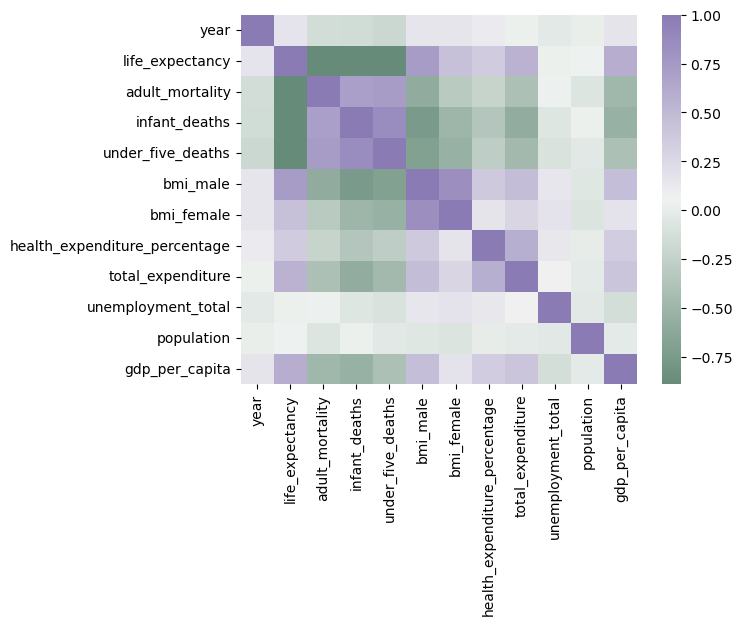

<Figure size 640x480 with 0 Axes>

In [65]:
# Dropping countries with missing values for columns adult_mortality, infant_deaths, under_five_deaths, health_expenditure_percentage, total_expenditure or unemployment_total does not affect correlation
#na_countries = ['Côte d\'Ivoire', 'Netherlands', 'The former Yugoslav republic of Macedonia', 'Turkey']
#life_expectancy_heatmap = life_expectancy[~(life_expectancy['country'].isin(na_countries))]

life_expectancy_heatmap = life_expectancy.drop(columns='country')

colors = sns.diverging_palette(150, 275, s=40, l=55, as_cmap=True)
sns.heatmap(life_expectancy_heatmap.corr(),cmap=colors, robust=False)
plt.show()
plt.clf()


## Scatterplots

### Life Expectancy vs GDP

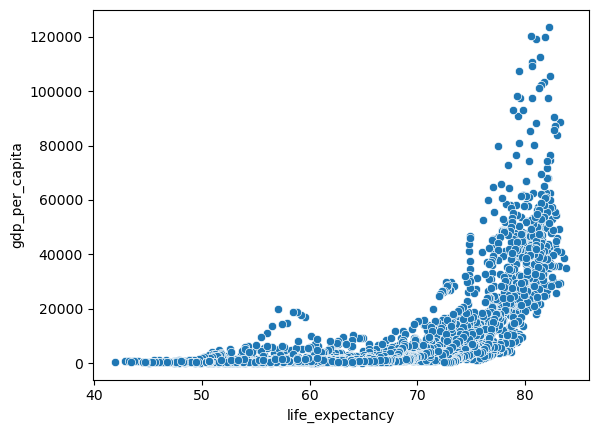

[[8.32029763e+01 9.21482124e+04]
 [9.21482124e+04 2.90852372e+08]]
0.5923537995114241


<Figure size 640x480 with 0 Axes>

In [66]:
sns.scatterplot(x=life_expectancy['life_expectancy'], y=life_expectancy['gdp_per_capita'])
plt.show()
plt.clf()

print(np.cov(life_expectancy['life_expectancy'], life_expectancy['gdp_per_capita']))
cor_life_exp_gdp, p = pearsonr(life_expectancy['life_expectancy'], life_expectancy['gdp_per_capita'])
print(cor_life_exp_gdp)


### Life Expectancy vs Male BMI

In [67]:
gdp_class = []
for gdp in list(life_expectancy['gdp_per_capita']):
    if gdp >= 15000:
        gdp_class.append('more than 15,000')
    else:
        gdp_class.append('less than 15,000')

life_expectancy['gdp_class'] = gdp_class

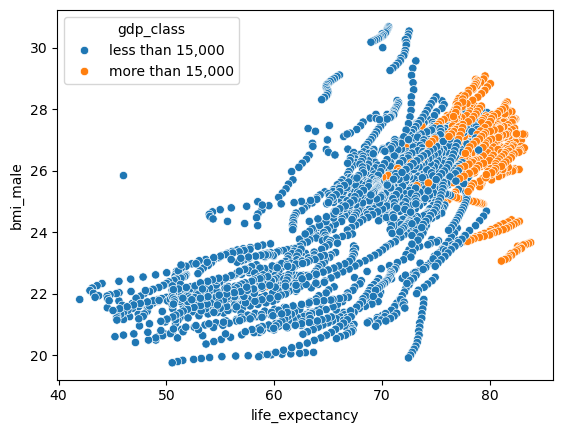

<Figure size 640x480 with 0 Axes>

In [68]:
sns.scatterplot(x=life_expectancy['life_expectancy'], y=life_expectancy['bmi_male'], hue=life_expectancy['gdp_class'])
plt.show()
plt.clf()

### Life Expectancy vs Female BMI

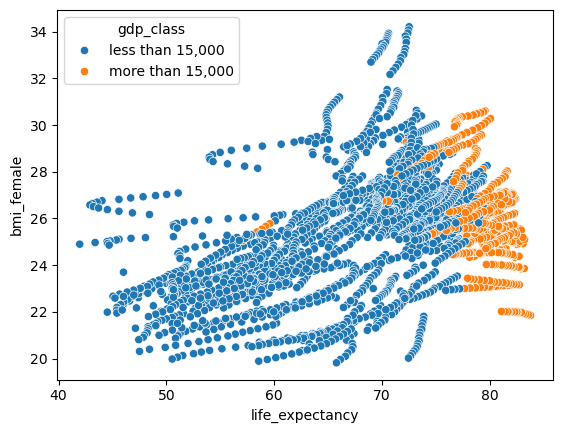

<Figure size 640x480 with 0 Axes>

In [69]:
sns.scatterplot(x=life_expectancy['life_expectancy'], y=life_expectancy['bmi_female'], hue=life_expectancy['gdp_class'])
plt.show()
plt.clf()


### Life Expectancy vs Adult Mortality

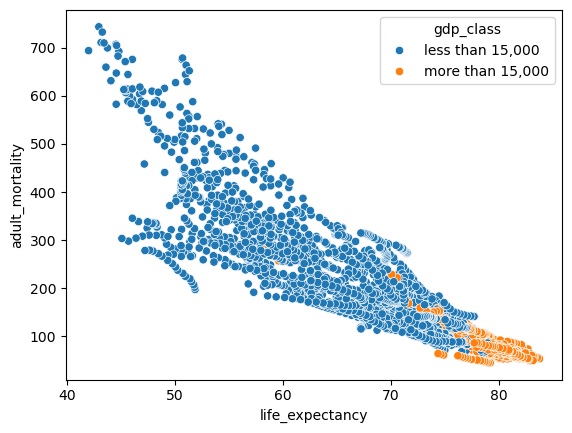

<Figure size 640x480 with 0 Axes>

In [70]:
sns.scatterplot(x=life_expectancy['life_expectancy'], y=life_expectancy['adult_mortality'], hue=life_expectancy['gdp_class'])
plt.show()
plt.clf()

In [71]:
print(np.cov(life_expectancy['life_expectancy'], life_expectancy['adult_mortality']))
cor_life_exp_ad_mortality, p = pearsonr(life_expectancy['life_expectancy'], life_expectancy['adult_mortality'])
print(np.round(cor_life_exp_ad_mortality, 2))


[[   83.20297629  -952.85317627]
 [ -952.85317627 13720.40524064]]
-0.89


### Life Expectancy vs Infant Mortality

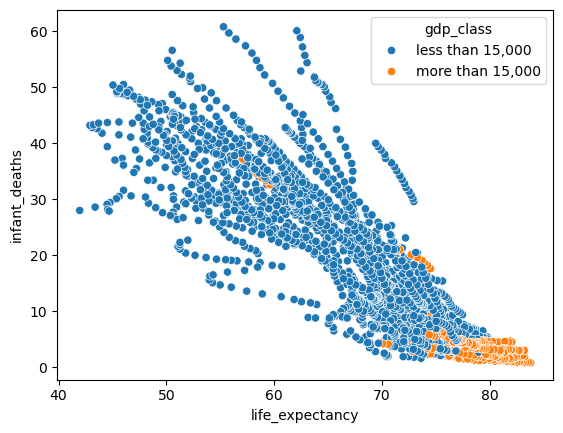

<Figure size 640x480 with 0 Axes>

In [72]:
sns.scatterplot(x=life_expectancy['life_expectancy'], y=life_expectancy['infant_deaths'], hue=life_expectancy['gdp_class'])
plt.show()
plt.clf()

### Life Expectancy vs Under 5 Mortality

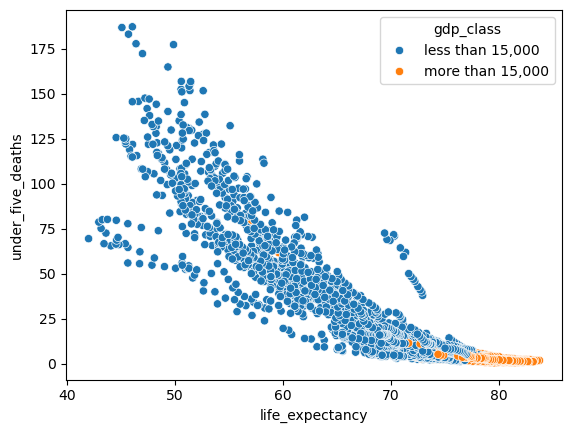

<Figure size 640x480 with 0 Axes>

In [73]:
sns.scatterplot(x=life_expectancy['life_expectancy'], y=life_expectancy['under_five_deaths'], hue=life_expectancy['gdp_class'])
plt.show()
plt.clf()

In [74]:
high_gdp_outlier = life_expectancy[(life_expectancy['life_expectancy'] < 60) & (life_expectancy['gdp_class'] == 'more than 15,000')]
print(np.unique(high_gdp_outlier['country']))
print(descriptive_stats_life_exp)


['Equatorial Guinea']
    year   mean    max max_countries  minimum min_countries  median
0   2000  66.68  81.08         Japan    44.52        Malawi   69.74
1   2001  67.01  81.42         Japan    41.96      Zimbabwe   69.94
2   2002  67.29  81.69         Japan    44.56      Zimbabwe   70.42
3   2003  67.57  81.76         Japan    43.39      Zimbabwe   70.53
4   2004  67.93  82.03         Japan    43.71       Lesotho   70.85
5   2005  68.28  81.96         Japan    43.23       Lesotho   71.19
6   2006  68.66  82.32         Japan    42.91       Lesotho   71.18
7   2007  69.00  82.51         Japan    43.12       Lesotho   71.40
8   2008  69.33  82.59         Japan    43.57       Lesotho   71.63
9   2009  69.74  82.93         Japan    44.03       Lesotho   71.91
10  2010  70.03  82.84         Japan    45.60       Lesotho   72.32
11  2011  70.49  82.70   Switzerland    46.69       Lesotho   72.49
12  2012  70.78  83.10         Japan    47.84       Lesotho   72.56
13  2013  71.07  83.33    

## Box Plots

### Life Expectancy vs GDP

Create boxplots for 20 Lowest grosing countries over the last 20 years

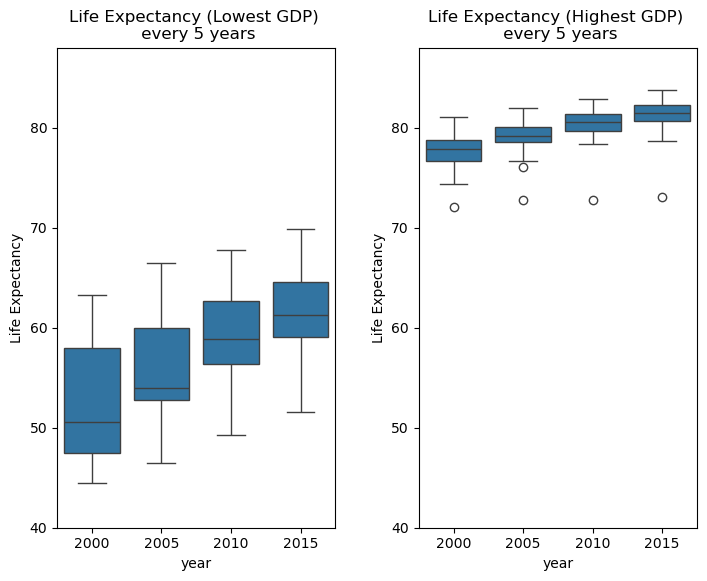

<Figure size 640x480 with 0 Axes>

In [75]:
le_bottom_2000_and_2015 = lowest_grossing[(lowest_grossing['year'] == 2000) | (lowest_grossing['year'] == 2015) | (lowest_grossing['year'] == 2005) | (lowest_grossing['year'] == 2010)]
le_bottom_2000_to_2015 = lowest_grossing

le_top_2000_and_2015 = highest_grossing[(highest_grossing['year'] == 2000) | (highest_grossing['year'] == 2015) | (highest_grossing['year'] == 2005) | (highest_grossing['year'] == 2010)]
le_top_2000_to_2015 = highest_grossing

ax1 = plt.subplot(1, 2, 1)
sns.boxplot(x = le_bottom_2000_and_2015['year'], y = le_bottom_2000_and_2015['life_expectancy'])
plt.title('Life Expectancy (Lowest GDP) \n every 5 years')
plt.ylabel('Life Expectancy')
plt.subplots_adjust(0, 1, 1, 2, 0.3, 0)
plt.ylim(40, 88)
ax3 = plt.subplot(1, 2, 2)
sns.boxplot(x = le_top_2000_and_2015['year'], y = le_top_2000_and_2015['life_expectancy'])
plt.title(label='Life Expectancy (Highest GDP) \n every 5 years')
plt.ylabel('Life Expectancy')
plt.ylim(40, 88)
plt.show()
plt.clf()


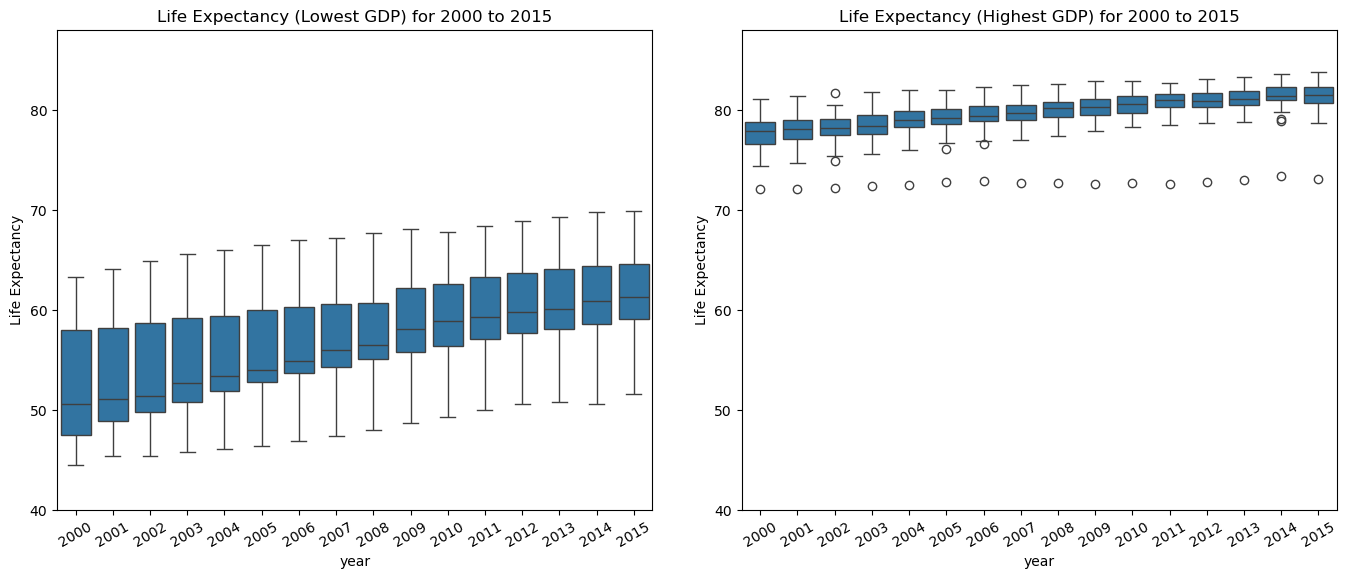

<Figure size 640x480 with 0 Axes>

In [76]:

ax2 = plt.subplot(1, 2, 1)
sns.boxplot(x = le_bottom_2000_to_2015['year'], y = le_bottom_2000_to_2015['life_expectancy'])
plt.title('Life Expectancy (Lowest GDP) for 2000 to 2015')
plt.ylabel('Life Expectancy')
plt.xticks(rotation = 30)
plt.ylim(40, 88)
plt.subplots_adjust(0, 1, 2, 2, 0.15, 0)
ax4 = plt.subplot(1, 2, 2)
sns.boxplot(x = le_top_2000_to_2015['year'], y = le_top_2000_to_2015['life_expectancy'])
plt.title('Life Expectancy (Highest GDP) for 2000 to 2015')
plt.ylabel('Life Expectancy')
plt.xticks(rotation = 30)
plt.ylim(40, 88)
plt.show()
plt.clf()